In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\vishe\Downloads\Indian-Resturants.csv")

In [3]:
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [4]:
df.shape

(211944, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   url                   211944 non-null  object 
 4   address               211810 non-null  object 
 5   city                  211944 non-null  object 
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  object 
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   object 
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  object 
 13  cuisines              210553 non-null  object 
 14  timings               208070 non-null  object 
 15  

In [6]:
df.isnull().sum()

res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

In [12]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(151527)

In [8]:
df = df.drop_duplicates()

In [10]:
# Average Rating

In [14]:
df['aggregate_rating'].mean()

np.float64(3.032868232451132)

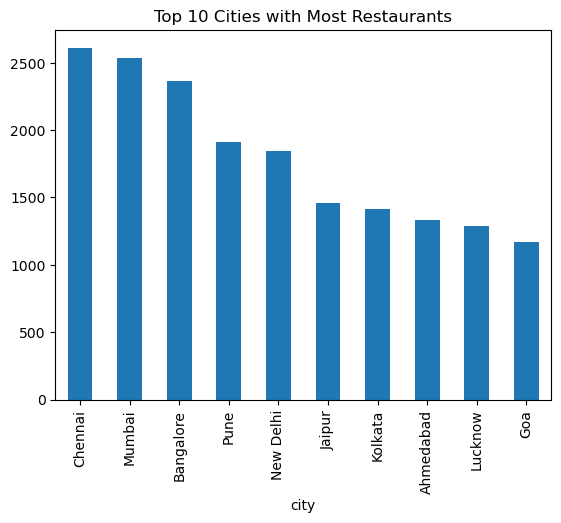

In [16]:
df['city'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cities with Most Restaurants")
plt.show()

In [17]:
#Most Popular Cuisines

In [18]:
df['cuisines'].value_counts().head(10)

cuisines
North Indian             4587
Fast Food                2137
North Indian, Chinese    1720
Bakery                   1618
South Indian             1600
Street Food              1221
Cafe                     1180
Mithai                   1032
Desserts                  950
Bakery, Desserts          872
Name: count, dtype: int64

In [ ]:
#Price Range vs Rating

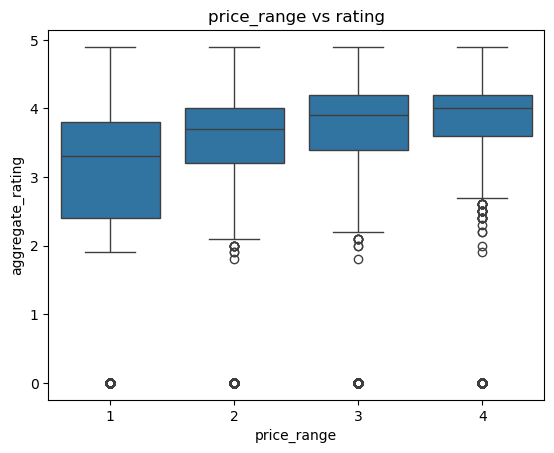

In [20]:
sns.boxplot(x='price_range', y='aggregate_rating', data=df)
plt.title("price_range vs rating")
plt.show()

In [ ]:
# Online Order Impact

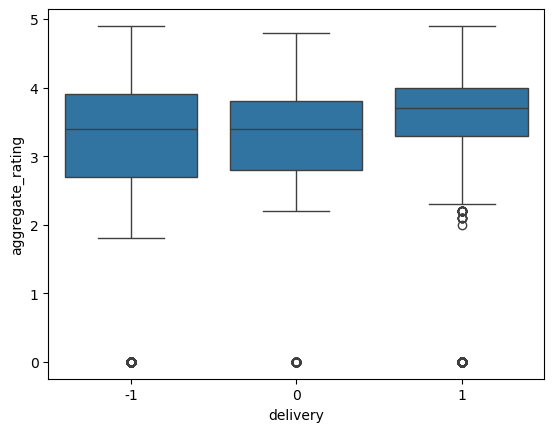

In [22]:
sns.boxplot(x='delivery', y='aggregate_rating', data=df)
plt.show()

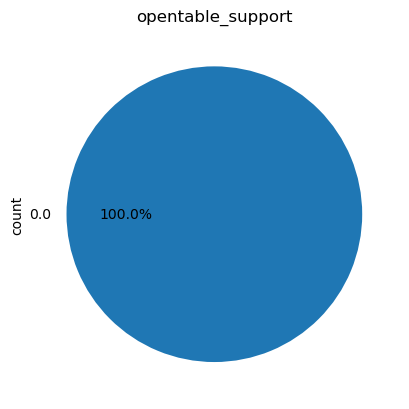

In [23]:
df['opentable_support'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("opentable_support")
plt.show()

In [24]:
# Top Restaurant Chains

In [26]:
df['name'].value_counts().head(10)

name
Domino's Pizza     406
Cafe Coffee Day    323
KFC                261
Subway             211
Keventers          208
Baskin Robbins     207
McDonald's         155
Pizza Hut          150
Burger King        144
Barbeque Nation    120
Name: count, dtype: int64

In [30]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


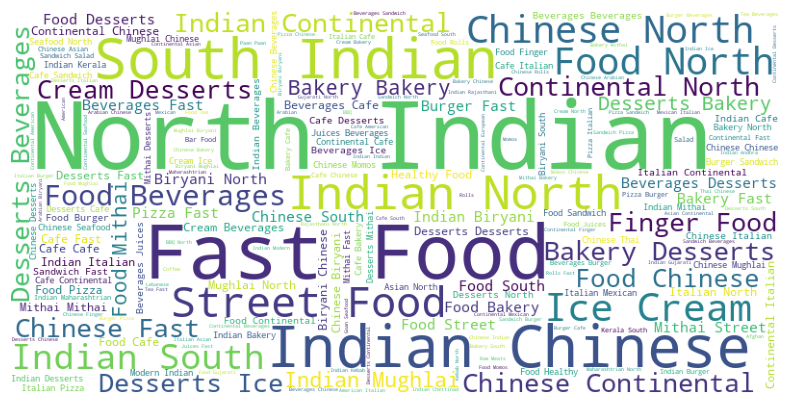

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cuisines'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Based on the analysis, the key factors influencing restaurant success include city location, availability of online delivery, price range, and cuisine type. Restaurants offering online delivery and table booking tend to have slightly higher ratings. Popular cuisines attract more customers, while mid-range pricing appears to balance affordability and quality perception.